### Data Load

In [6]:
import warnings
warnings.filterwarnings("ignore")

import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

RANDOM_STATE = 42
DATA_PATH = "train.csv"
CREDIT_LABELS = ["Low (0)", "Mid (1)", "High (2)"]
CREDIT_COLORS = ["red", "blue", "green"]

df = pd.read_csv('train.csv')

In [2]:
df.head()

,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,Description,PhotoAmt,AdoptionSpeed
0,Dog,2,Mixed Breed,Female,Black,Brown,Medium,Short,No,No,Healthy,0,Mylo is among three siblings found by a friend...,7,2
1,Cat,24,Domestic Medium Hair,Female,Cream,No Color,Medium,Medium,Yes,Yes,Healthy,20,A bit shy and timid..but she is loving and can...,3,1
2,Dog,12,Spitz,Female,White,No Color,Medium,Medium,Not Sure,Not Sure,Healthy,0,Seeking adopters for this sweet girl. She was ...,4,4
3,Dog,12,Pug,Male,Black,Cream,Small,Short,Yes,Yes,Healthy,0,Lucas is a sturdy little dog. Very well behave...,6,3
4,Dog,3,Mixed Breed,Male,Black,No Color,Medium,Short,Not Sure,Not Sure,Healthy,0,"Hi, I'm Randy, few weeks ago I got beaten by h...",2,4


- 0. 어떤 데이터가 들어있는지 탐색하세요.
- 0. Description Featrure 는 삭제하세요.
--------------------------------
- 0. Explore what features are included in the dataset
- 0. Drop the 'Description' feature

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10383 entries, 0 to 10382
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Type           10383 non-null  object
 1   Age            10383 non-null  int64 
 2   Breed1         10383 non-null  object
 3   Gender         10383 non-null  object
 4   Color1         10383 non-null  object
 5   Color2         10383 non-null  object
 6   MaturitySize   10383 non-null  object
 7   FurLength      10383 non-null  object
 8   Vaccinated     10383 non-null  object
 9   Sterilized     10383 non-null  object
 10  Health         10383 non-null  object
 11  Fee            10383 non-null  int64 
 12  Description    10374 non-null  object
 13  PhotoAmt       10383 non-null  int64 
 14  AdoptionSpeed  10383 non-null  int64 
dtypes: int64(4), object(11)
memory usage: 1.2+ MB


### Data EDA

- 1. Print Data shape 
- 2. 데이터 정보 infor 를 보고 데이터를 파악하세요.

결측치 유무, 수치형/범주형 데이터 파악하고 markdown을 이용해서아래에 결과 summary 하세요.

-----------------------

- 1. Print the data shape.
- 2. Check the data information using info() and understand the dataset.

Identify whether there are missing values and determine which variables are numerical or categorical. Then, use Markdown to summarize the results below.

In [4]:
print(df.shape)

(10383, 15)


- 3. 수치형 변수 | 범주형 변수를 나누세요. 
--------------------------------
- 3. Separate numerical variables and categorical variables.

- 4. 수치형 변수를 시각화하고 각 데이터에 대해 전처리 방법을 고안해보세요. (적용할 것이 없으면 넘어감)
--------------------------------
- 4. Visualize the numerical variables and consider appropriate preprocessing methods for each variable. If no preprocessing is needed, you may skip it.

- 5. 클래스 분포 시각화하고 데이터 분석에 있어서 우려되는 점을 기술하세요.
--------------------------------
- 5. Visualize the class distribution and describe any concerns for data analysis.

- 6. 범주형 변수 분포를 시각화하고 전처리 방법은 고안해보세요. (적용할 것이 없으면 넘어감)
- 7. 범주형 변수처리에 있어 Label encoding, onehot encoding 방식이 있다. 아래 내용을 고민해보세요.

    - Label encoding을 적용할 경우 어울리는 모델은?
    - Label encoding을 적용할 경우 우려되는 점은?
    - Onehot encoding을 해야되는 모델은?
    - Breed1 는 어떻게 처리하면 좋을지 고민하세요.

--------------------------------------------------
- 6. Visualize the distribution of categorical variables and consider appropriate preprocessing methods. If no preprocessing is needed, you may skip it.
- 7. There are two common methods for handling categorical variables: Label Encoding and One-Hot Encoding. Consider the following questions:
    - Which models are suitable when Label Encoding is applied?
    - What concerns may arise when Label Encoding is applied?
    - Which models require One-Hot Encoding?
    - Consider how Breed1 should be handled.

,nunique,top,top_rate(%)
Type,2,Dog,57.29
Breed1,161,Mixed Breed,40.19
Gender,2,Female,55.82
Color1,7,Black,45.55
Color2,7,No Color,34.34
MaturitySize,3,Medium,69.55
FurLength,3,Short,58.26
Vaccinated,3,Yes,43.89
Sterilized,3,No,64.99
Health,3,Healthy,96.13


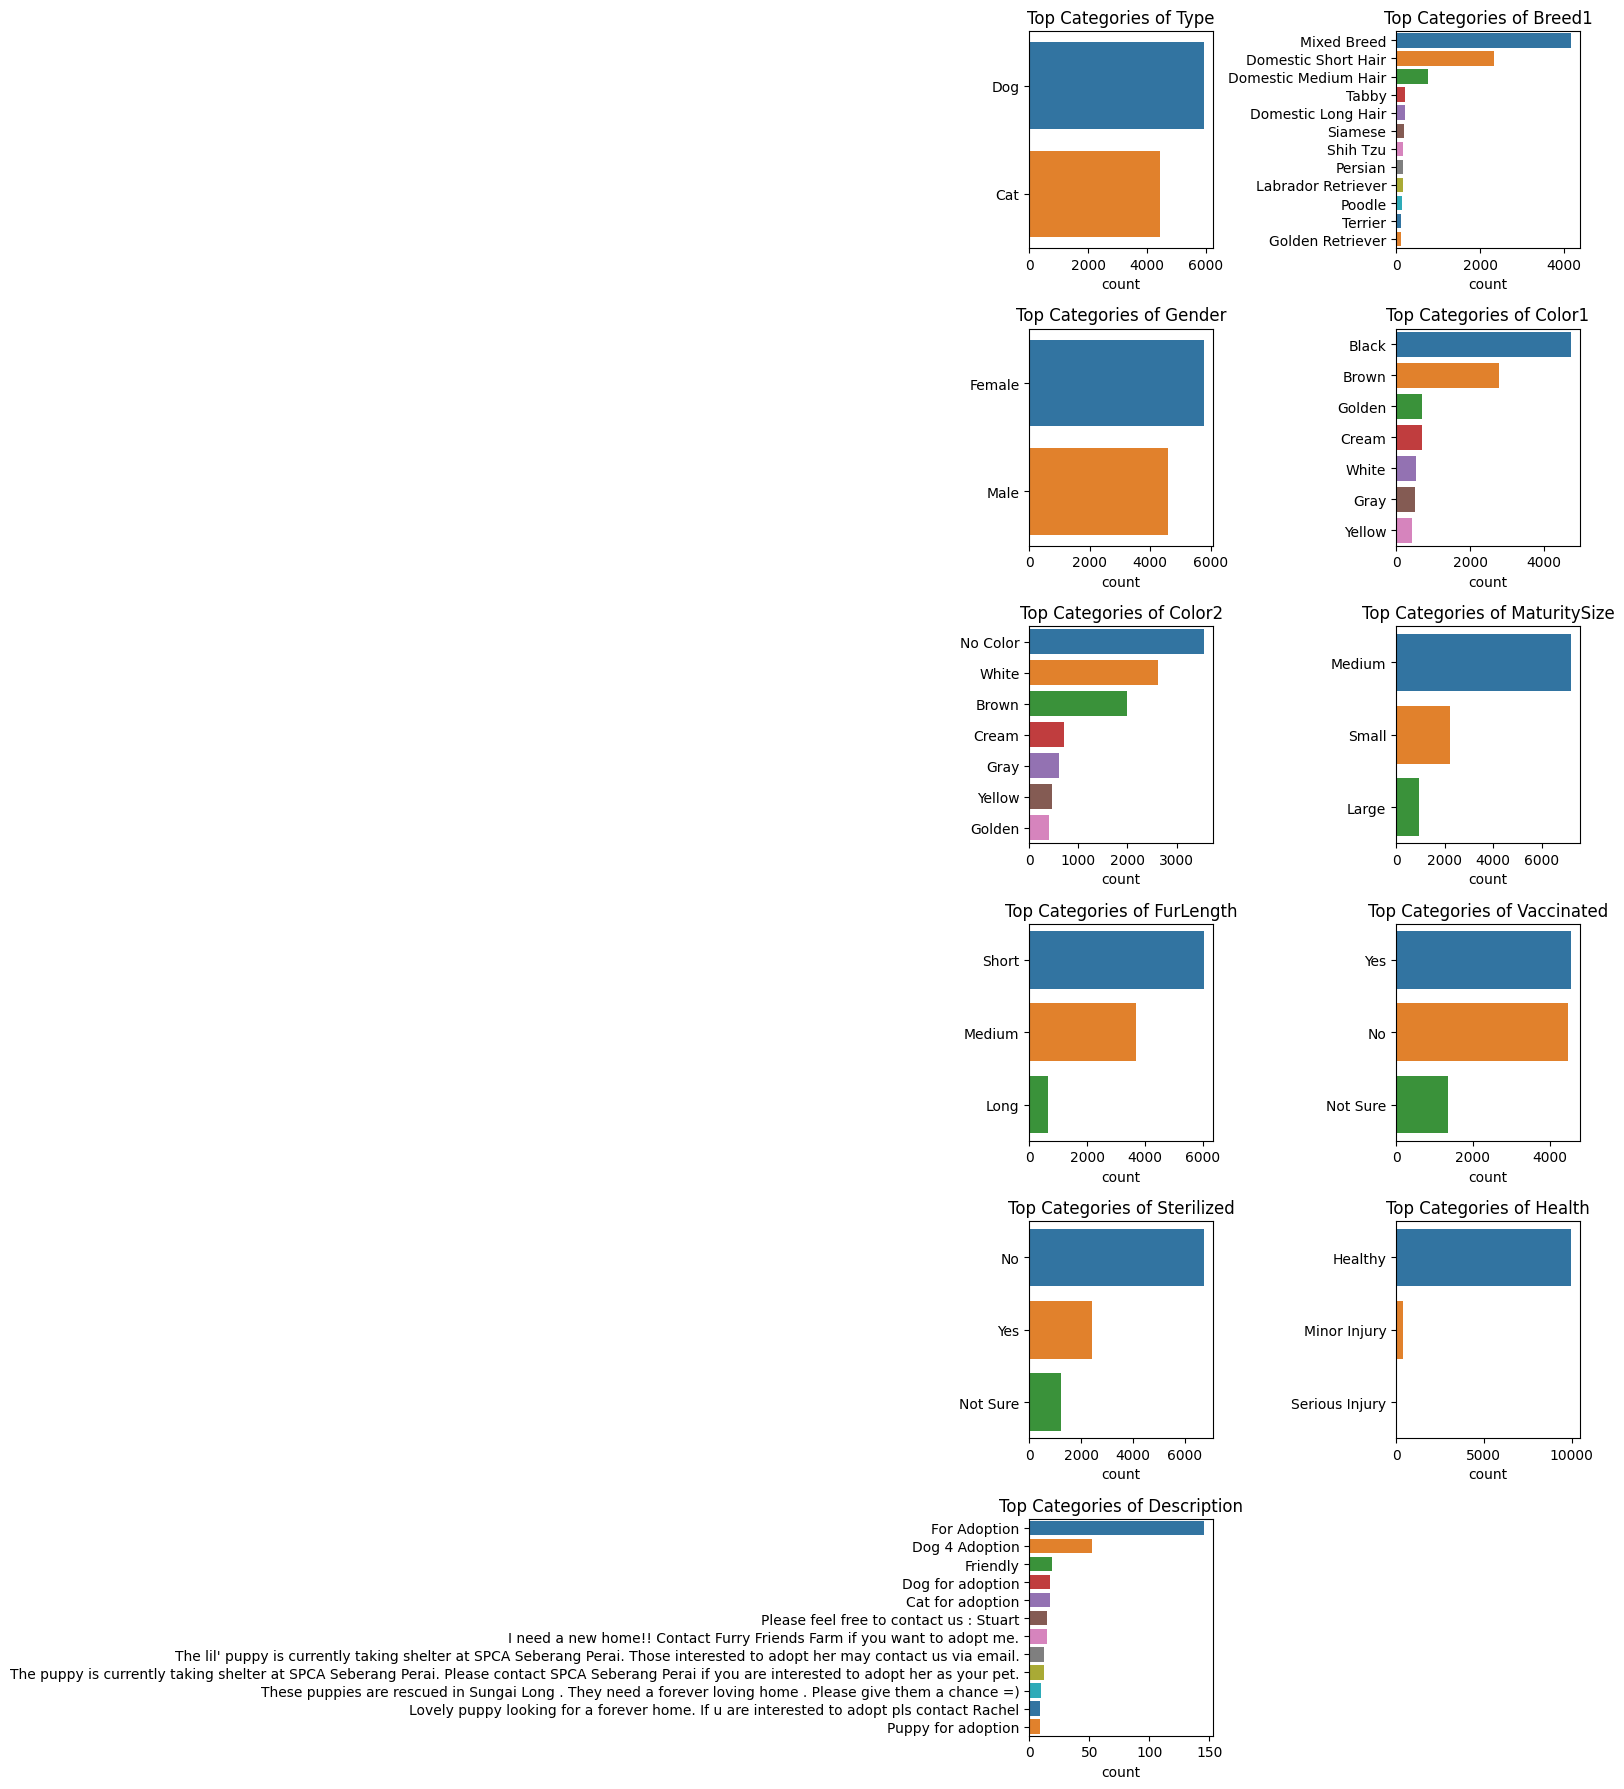

In [8]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
cat_summary = pd.DataFrame({
    "nunique": df[categorical_cols].nunique(dropna=False),
    "top": [df[c].fillna("Missing").mode().iloc[0] for c in categorical_cols],
    "top_rate(%)": [(df[c].fillna("Missing").value_counts(normalize=True).iloc[0] * 100).round(2) for c in categorical_cols],
}, index=categorical_cols)
display(cat_summary)

fig, axes = plt.subplots(6, 2, figsize=(16, 18))
axes = axes.ravel()
for i, col in enumerate(categorical_cols):
    order = df[col].fillna("Missing").value_counts().index[:12]
    sns.countplot(data=df.fillna("Missing"), y=col, order=order, ax=axes[i], palette="tab10")
    axes[i].set_title(f"Top Categories of {col}")
    axes[i].set_ylabel("")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()


- 8. 위 인코딩 전략을 적용하여 실제로 인코딩을 진행하세요.
--------------------------------
- 8. Apply the encoding strategy above and actually perform the encoding.

### Feature Selection

- 9. Correlation 분석을 실시하고 feature selection 진행하세요.
- 10. Mutual Information 이 무엇인지 파악하세요. Correlation과 차이점을 파악하세요.
- 11. 9번에 이어서 Mutual Information 기반의 feature selection 진행하세요. (시각화도 하세요.)
-----------------------------------
- 9. Conduct correlation analysis and perform feature selection.
- 10. Understand what Mutual Information is and identify the differences between Mutual Information and Correlation.
- 11. Following Question 9, perform feature selection based on Mutual Information. Also visualize the results.

### Modeling

- 12. 위 학습 전략을 적용하여 전체 데이터 처리 파이프라인 만들고 데이터 정제하기
- 13. 학습을 위해 Train test split 을 이용해 데이터 8:2로 나누기
--------------------------------
- 12. Build a complete data preprocessing pipeline based on the strategies above and clean the dataset.
- 13. Split the data into training and test sets using an 8:2 ratio with train_test_split.

- 14. 적절한 모델 3가지 이상을 설정하고 학습하기 (모델 선택 이유는?)
--------------------------------
- 14. Select and train at least three appropriate models. Explain why you selected those models.

### Evaluation

- 15. 모델 평가 메트릭을 정하고 평가하기, 평가결과 분석하기 (시각화 필수)
- 16. Class weight / Optuna 적용해서 최적화하기
--------------------------------
- 15. Choose suitable model evaluation metrics, evaluate the models, and analyze the evaluation results. Visualization is required.
- 16. Apply class_weight and/or Optuna to optimize the model.

### Interpretation with SHAP

- 17. shap을 이용해 결과 분석하기
    - 입양 속도에 영향을 미치는 중요한 인자는?
    - 해당인자가 어떤 값을 가질 때 입양속도가 빨라지는가?
    - 통제 가능한 변수는 무엇이고 어떻게 활용 하면 좋은가?
--------------------------------
- 17. Analyze the results using SHAP.
    - What are the important factors that affect adoption speed?
    - When those factors have certain values, does the adoption speed become faster?
    - What are the controllable variables, and how can they be effectively utilized?